In [1]:
import sys

sys.path.append("../")
import numpy as np
import matplotlib.pyplot as plt

#load the necessary odometry modules
from odometry.datasets.map_handler import MapHandler
from odometry.datasets.radnav_ds import radnavDS
from odometry.test_benches.temporal_pc_stacking_pf_tb import temporalCombinedPCPFTb
from odometry.localization.icp2D_localization import icp2DLocalization
from odometry.localization.particle_filter import particleFilter
from odometry.estimators.motion_models import GyroEncoderIntegratorMM,OdometryMM
from odometry.plotting.movies import MovieGenerator
from odometry.point_cloud_processing.temporal_pc_stacker import temporalPcStacker


/home/david/.cache/pypoetry/virtualenvs/odometry-u_DtWola-py3.11/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
from dotenv import load_dotenv
import os

#loading enviroment variables
load_dotenv()
DATASET_PATH=os.getenv("DATASET_DIRECTORY")
MAP_DIRECTORY=os.getenv("MAP_DIRECTORY")

#setup the datasets
folder_name = "WILK"
# file_name = "WILK_Multipath_Test_1"
# file_name = "WILK_Path_1_No_Dynamic"
file_name = "WILK_Path_1_Slow_Dynamic_1"

dataset = radnavDS(
    dataset_path=os.path.join(DATASET_PATH,folder_name,file_name), #_spin_recall
    radar_folder="radar_combined",
    lidar_folder="lidar",
    camera_folder="camera",
    imu_orientation_folder="imu_data",
    imu_full_folder="imu_data_full",
    vehicle_vel_folder="vehicle_vel"
)

map_handler = MapHandler(
    maps_folder=MAP_DIRECTORY,
    map_file="wilkinson.yaml"
)

found 2491 radar samples
found 2491 lidar samples
found 2491 camera samples
found 2491 imu (orientation only) samples
found 2491imu (full data) samples
found 2491 vehicle velocity samples
loaded map from /data/radnav/maps/wilkinson.yaml
loaded map free space from /data/radnav/maps/wilkinson.yaml


In [3]:
#initialize the particle filter components


In [4]:
#initialize the particle filter
motion_model = OdometryMM(
    a1=0.01,
    a2=0.05,
    a3=0.05,
    a4=0.01,
    gyro_bias=-0.0024
)

particle_filter = particleFilter(
    motion_model=motion_model,
    max_particles=1000,
    measurement_model_sigma=0.3,
    measurement_model_z_rand = 0.2,
    measurement_model_z_hit = 0.8
)

lidar_odometry = icp2DLocalization(
    icp_matching_distance_threshold=0.6,
    icp_best_points_percentile=50,
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=10,
    icp_max_iterations=20,
    self_detection_radius_m=0.25
)

In [5]:
#initialize the point cloud stacker
pc_stacker = temporalPcStacker(
    num_frames_static_history = 4, # originally 4
    num_frames_dynamic_history = 0, # originally 0
    refresh_distance_m = 3, #originally 3
    refresh_rot_deg = 90, #originally 90
    refresh_time_s = 5, #originally 5
    grid_resolution_m = 5e-2, #originally 5e-2
    grid_max_distance_m = 20, #originally 20
    multi_path_clustering_eps = 0.5, #originally 0.5
    multi_path_clustering_min_samples = 15,  #originally 15
    multi_path_num_frames_history=4, # originally 4
    vel_filtering_enabled = True,
    vel_filtering_v_thresh = 0.05, # originally 0.05
    vel_filtering_min_static_rejection_radius = 0.25, #originally 0.25
    vel_filtering_dynamic_cluster_eps = 0.5, #originally 0.5
    vel_filtering_dynamic_cluster_min_samples = 15, #originally 15
    min_detection_radius_m=1.5, #originally 1.5
    max_detection_range_m=20, #originally 20
    gyro_bias=-0.0024 #originally -0.0024
)

loaded map with 20750 points
loaded map with 20750 points

loaded map with 20750 free points

gt icp estimated heading:-3.0480026825699658 deg, pose:[-0.38209145  0.15619829]


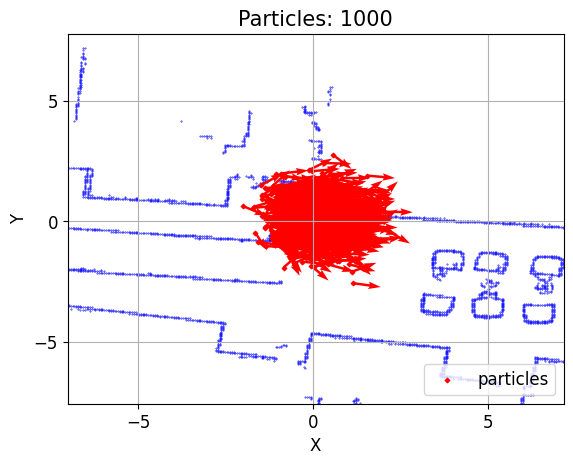

In [6]:
test_bench = temporalCombinedPCPFTb(
    localizer=particle_filter,
    gt_localizer=lidar_odometry,
    map_handler=map_handler,
    dataset=dataset,
    pc_stacker=pc_stacker
)

start_heading = np.deg2rad(0)
start_pose = np.array([0.03,0.11])

#initialize the localization
test_bench.init_localization(
    est_start_heading_rad=start_heading,
    est_start_pose_m=start_pose,
    n_particles=1000,
    show=True
)

#initialize the filter
test_bench.init_motion_model(
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

#initialize the point cloud stacker
test_bench.init_pc_stacker(
    start_time_s=test_bench.get_dataset_start_time(idx=0)
)

found temp dir: /home/david/Downloads/radnav_temp_dir
clearing temp directory /home/david/Downloads/radnav_temp_dir


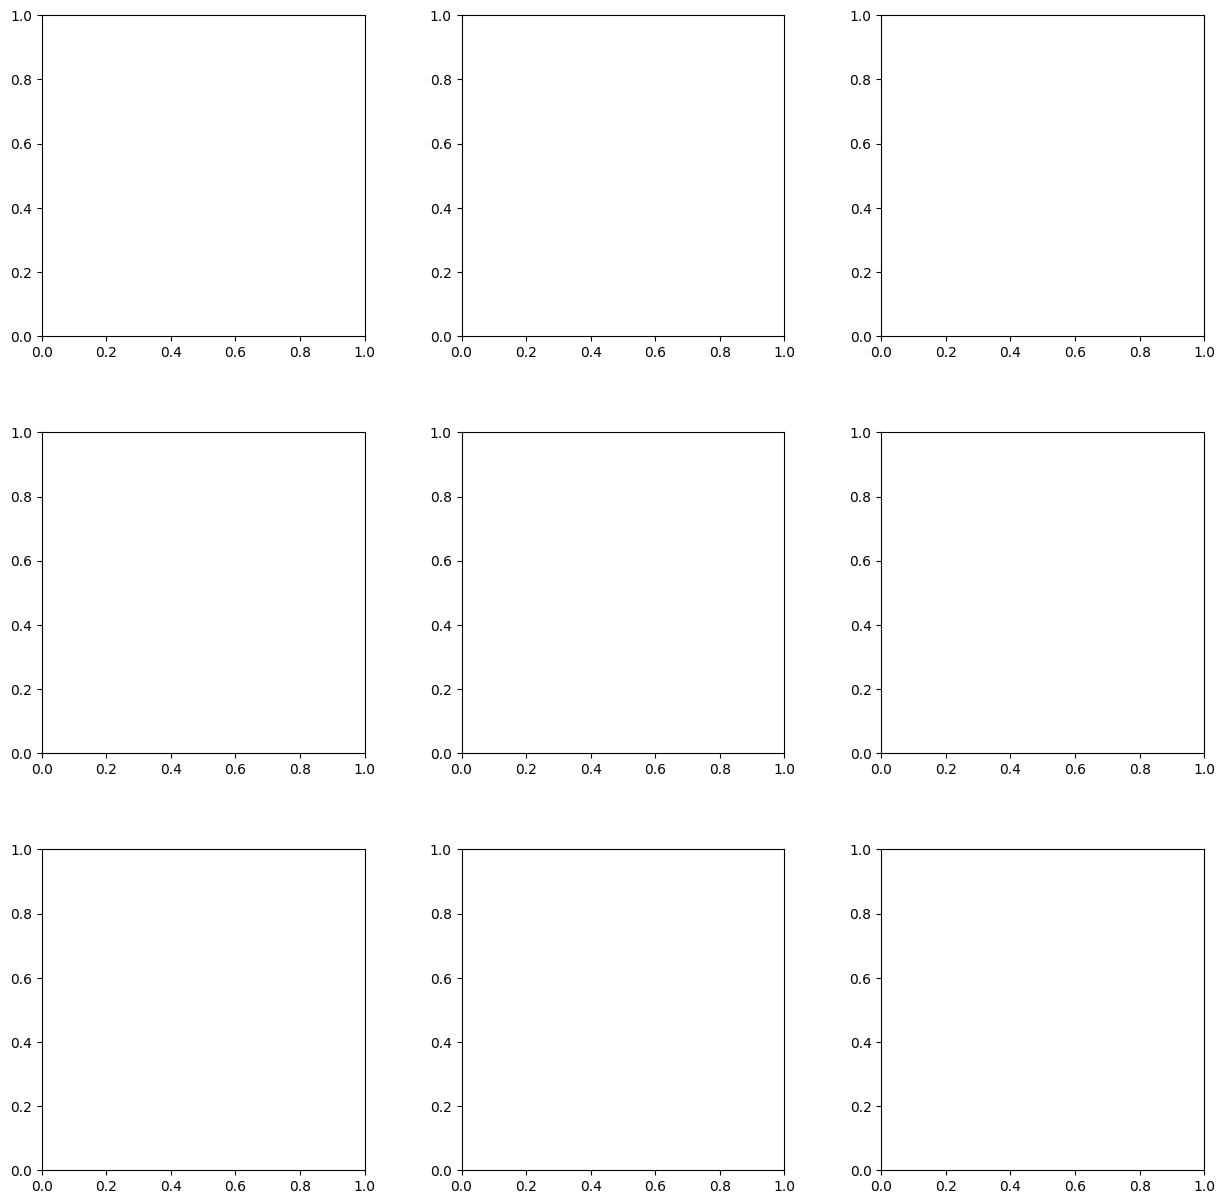

In [7]:
#loading directory from .env file
MOVIE_TEMP_DIRECTORY = os.getenv("MOVIE_TEMP_DIRECTORY")

#initialize the movie maker
movie_generator = MovieGenerator(
    temp_dir_path=MOVIE_TEMP_DIRECTORY
)
movie_generator.initialize_figure(
    nrows=3,
    ncols=3,
    figsize=(15,15)
)

In [8]:
end_idx = dataset.num_frames
save_name = file_name + "radar_combined"
test_bench.run(
    max_frame=end_idx,
    gt_enabled=False,
    movie_generator=None)#generator)

 88%|████████▊ | 2183/2491 [00:27<00:04, 62.98it/s]

frame 2208 is bad, (imu: 9,data: 10)


100%|██████████| 2491/2491 [00:33<00:00, 73.90it/s]


In [9]:
movie_generator.save_movie(video_file_name="{}.mp4".format(save_name),fps=20)

0it [00:00, ?it/s]


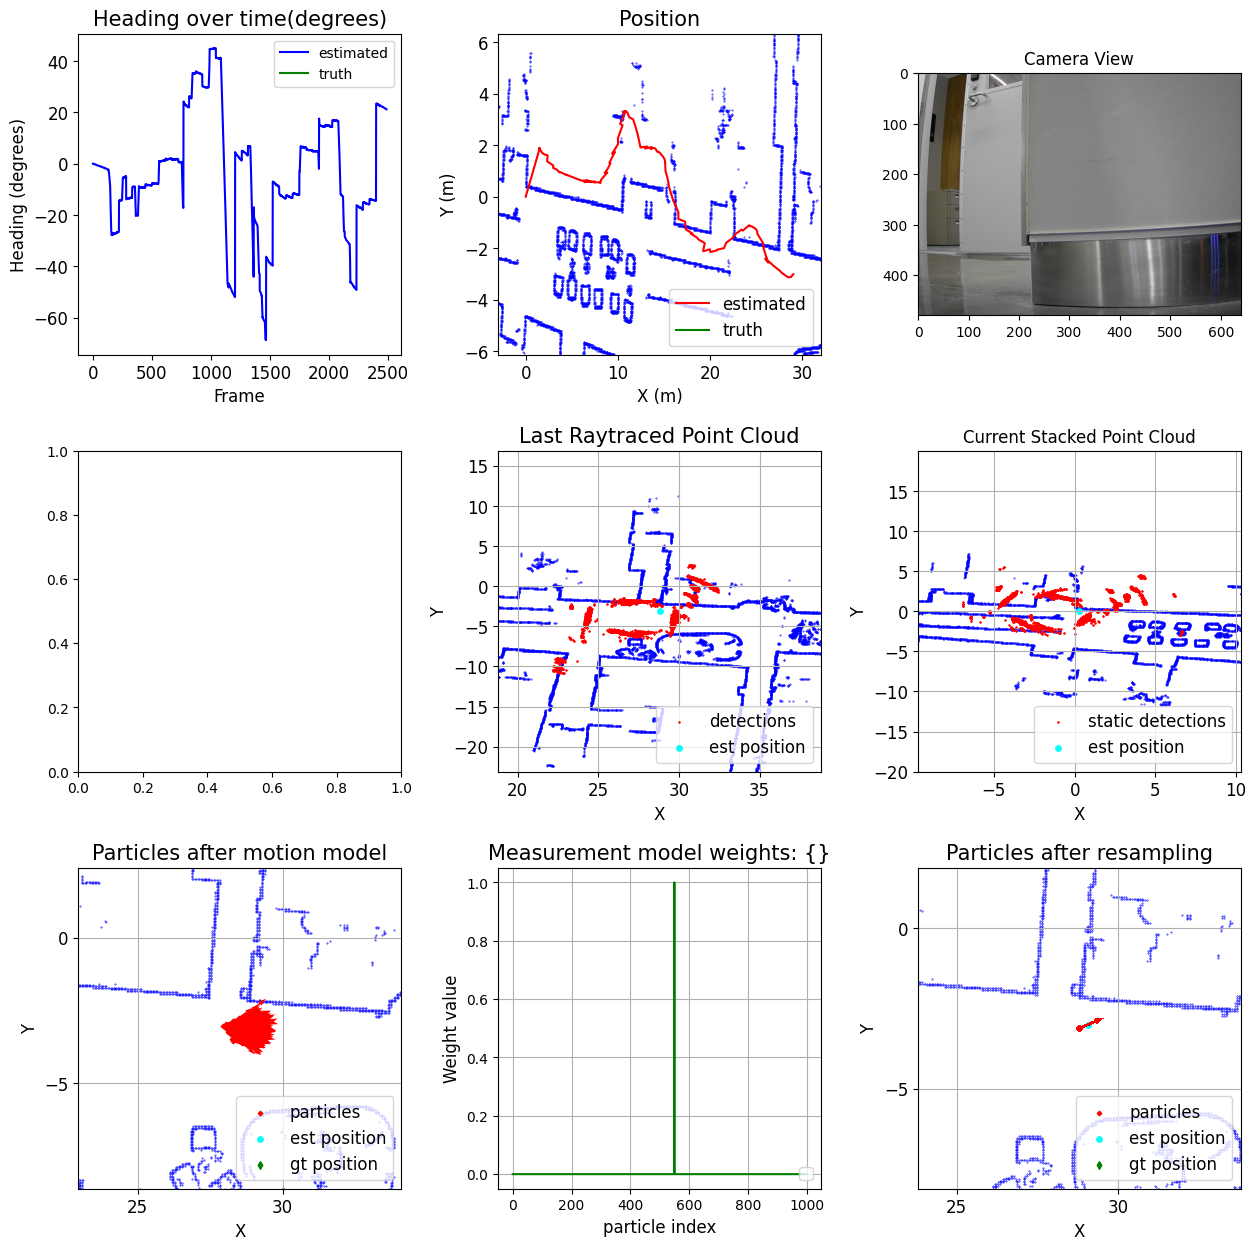

In [10]:
test_bench.plot_compilation(
    idx=end_idx-1,
    show=True
)

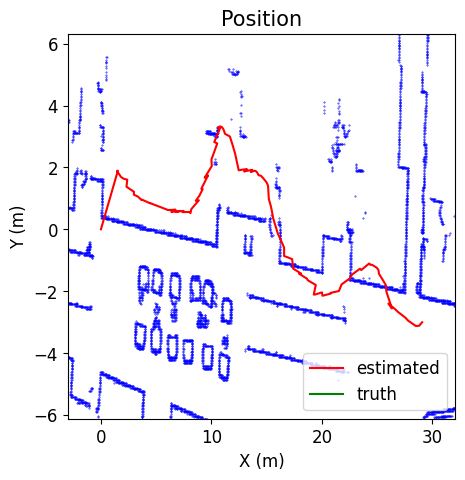

In [11]:
fig, axs = plt.subplots(figsize=(5,5))

test_bench.plotter_localization.plot_position_history_m(
    test_bench.history_position_m,
    test_bench.history_position_m_gt,
    idx=end_idx-1,
    ax=axs,
    show=True
)

fig.savefig("Images/position_history/{}.png".format(save_name))

In [14]:
print(test_bench.localizer.motion_model.x[0:3])
print(test_bench.gt_localizer.current_pose_m)
print(test_bench.point_cloud_stacker.integrator.x[0:3])
print(test_bench.point_cloud_stacker.initial_pose_m)
print(test_bench.point_cloud_stacker.current_pose_m)
print(np.linalg.norm(test_bench.gt_localizer.current_pose_m - test_bench.localizer.current_pose_m[0:2]))

[ 0.28996649 -0.00101272 -0.03846089]
[-0.38209145  0.15619829]
[ 0.52504808  0.16186781 -4.42430067]
[0.52504808 0.16186781]
[0.52504808 0.16186781]
29.612448130111186


In [15]:
#compute total distance traveled
dist = 0
for i in range(len(test_bench.history_position_m)-1):
    dist += np.linalg.norm(
        test_bench.history_position_m_gt[i+1] -\
        test_bench.history_position_m_gt[i]
    )

print(dist)

0.0


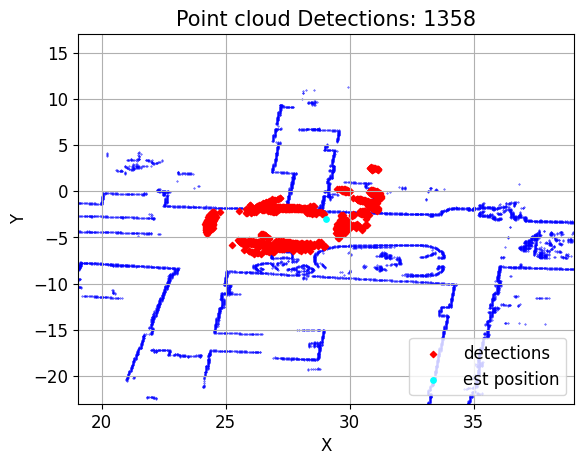

In [18]:
#debugging temporal pc stack
pc = test_bench.point_cloud_stacker.get_current_stacked_pc_static()
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)
test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.localizer.current_heading_rad,
    pose_m=test_bench.localizer.current_pose_m
)

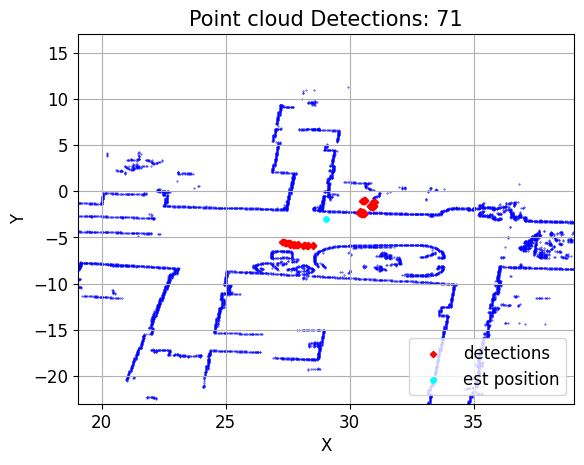

In [20]:
#debugging temporal pc stack
pc_grid = test_bench.point_cloud_stacker.pc_grid_static[0:1]
pc = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid)
pc = test_bench.point_cloud_stacker._change_pc_reference_frame(
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m,
    current_points=pc
)
pc = test_bench.point_cloud_stacker.multi_path.remove_multipath(pc)


test_bench.plotter_localization.plot_detections_on_map(
    current_points=pc,
    heading_rad=test_bench.localizer.current_heading_rad,
    pose_m=test_bench.localizer.current_pose_m
)

100%|██████████| 43/43 [00:00<00:00, 323.06it/s]


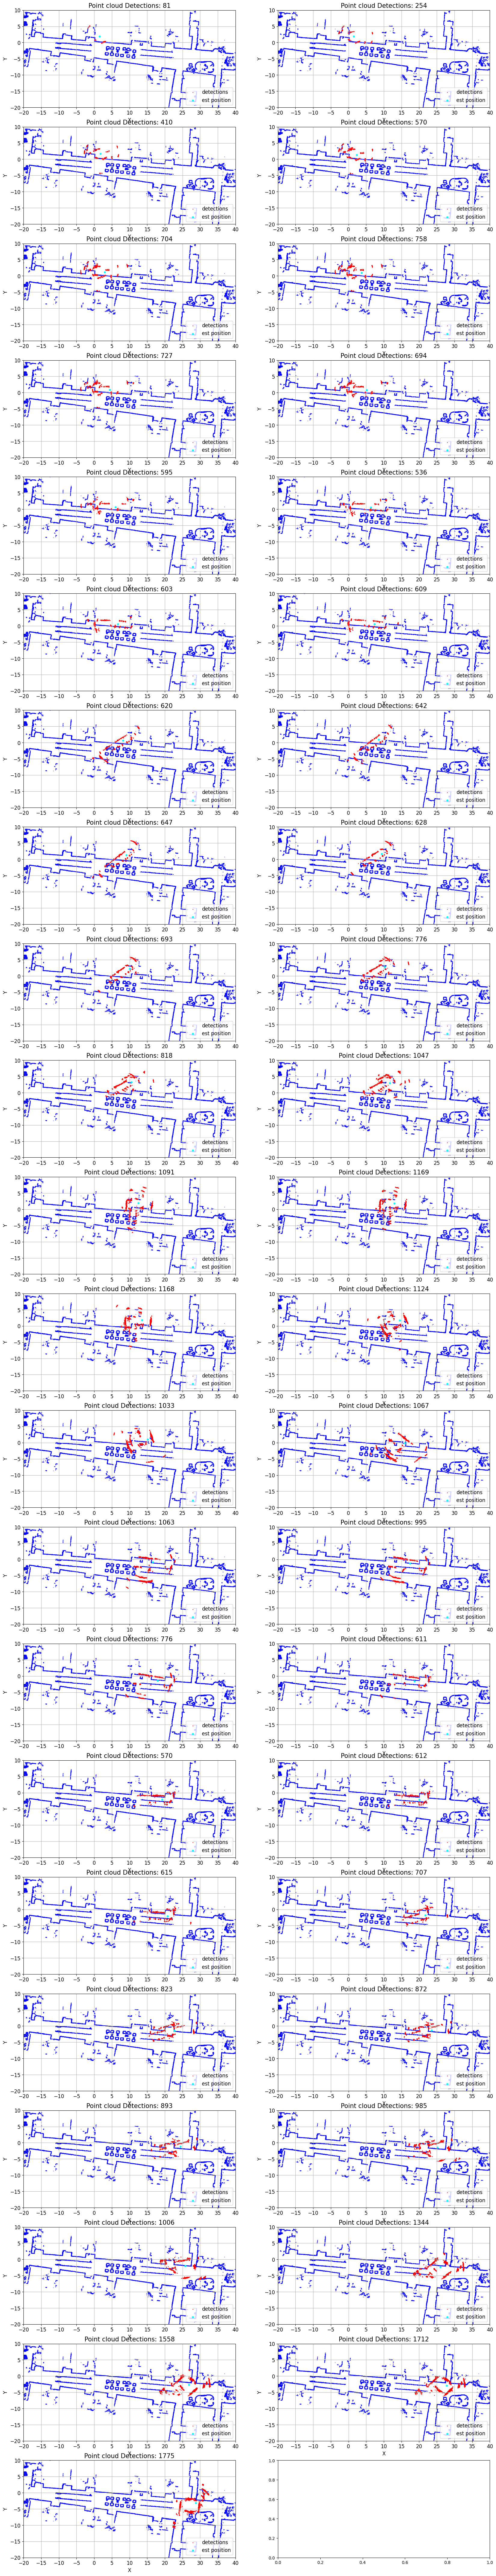

In [21]:
from tqdm import tqdm

r = int(len(test_bench.history_pc_stacker_point_clouds)/2) + 1
c = 2

fig, axs = plt.subplots(r, c, figsize = (20, 5 * r))

rc = 0
cc = 0
test_bench.plotter_localization.marker_size=0.5
for idx in tqdm(range(len(test_bench.history_pc_stacker_point_clouds))):
    test_bench.plotter_localization.plot_detections_on_map(
        current_points=test_bench.history_pc_stacker_point_clouds[idx],
        heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
        pose_m=test_bench.history_pc_stacker_position_m[idx],
        ax=axs[cc,rc],
        show=False
    )
    axs[cc,rc].set_ylim(-20,10)
    axs[cc,rc].set_xlim(-20, 40)
    rc += 1
    if(rc == c) :
        rc = 0
        cc += 1
        
# fig.savefig("Images/images/{}.png".format(save_name))
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

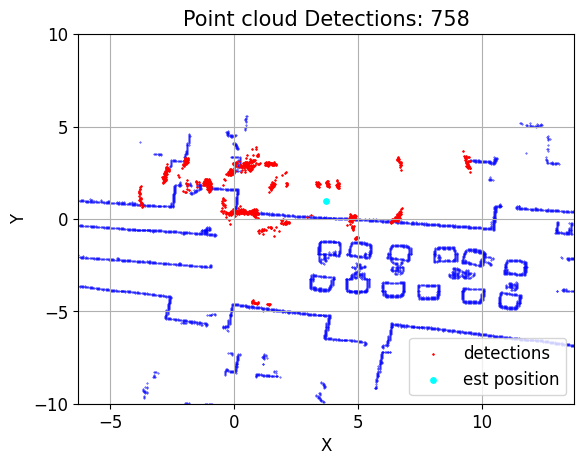

In [22]:
#plotting the saved ray traced point clouds
# plot the lidar point cloud
idx = 5
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5
test_bench.plotter_localization.plot_detections_on_map(
    current_points=test_bench.history_pc_stacker_point_clouds[idx],
    heading_rad=test_bench.history_pc_stacker_heading_rad[idx],
    pose_m=test_bench.history_pc_stacker_position_m[idx],
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show

In [23]:
test_bench.analyze()

TypeError: loop of ufunc does not support argument 0 of type NoneType which has no callable deg2rad method

## Evaluating Particle Filter History

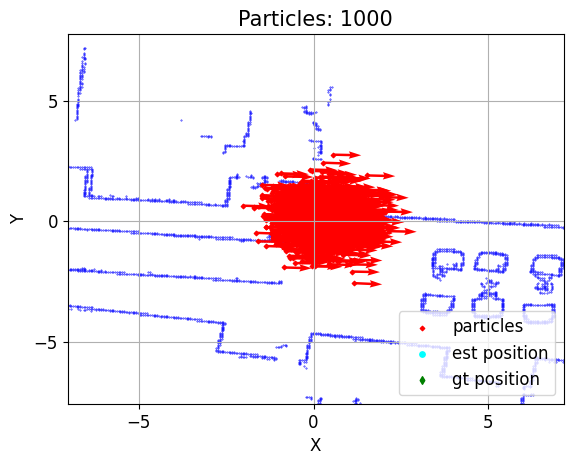

In [33]:
#particles after the motion model
idx = 0
particles = test_bench.history_particles_motion_model[idx]

test_bench.plotter_localization.plot_particles_on_map(
    particles=particles,
    est_pose_m=test_bench.gt_localizer.current_pose_m,
    gt_pose_m=test_bench.gt_localizer.current_pose_m,
    display_arrows=True,
    show=True
)

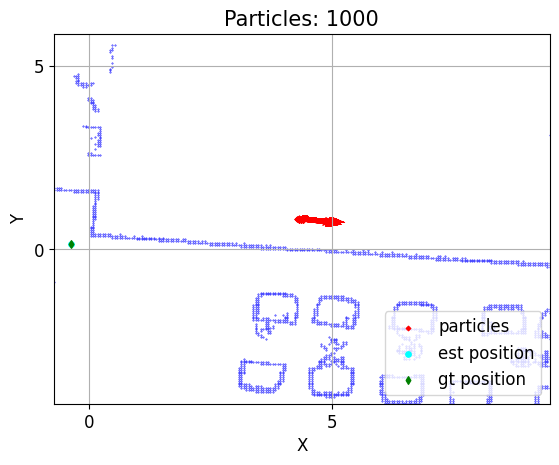

In [34]:
#particles after the measurement model
idx = 6
particles = test_bench.history_particles[idx]

test_bench.plotter_localization.plot_particles_on_map(
    particles=particles,
    est_pose_m=test_bench.gt_localizer.current_pose_m,
    gt_pose_m=test_bench.gt_localizer.current_pose_m,
    display_arrows=True,
    show=True
)

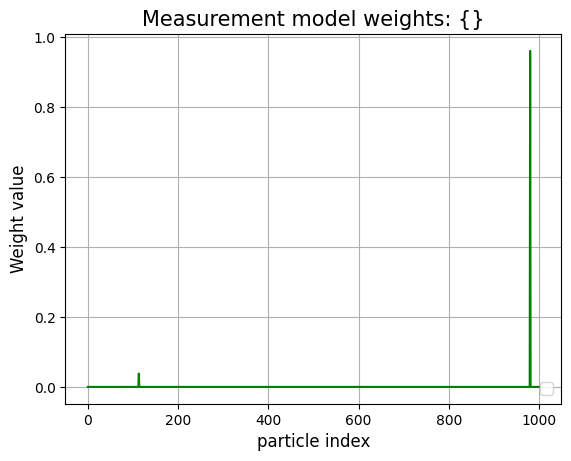

In [35]:
#computed weights
idx = 9
weights = test_bench.history_weights[idx]

test_bench.plotter_localization.plot_weights(
    weights=weights,
    show=True
)

## Debugging (testing ray tracing)

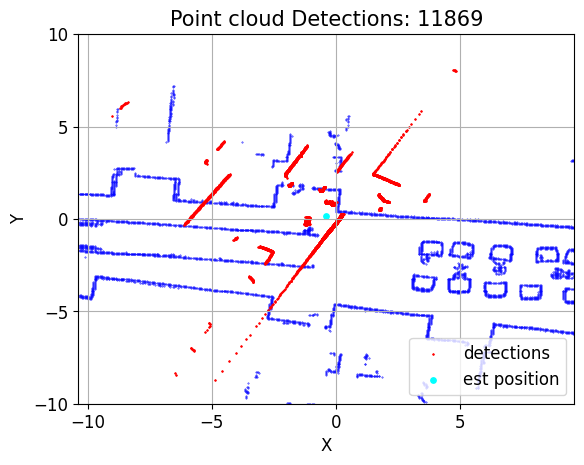

In [24]:
# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.plot_lidar_points_on_map(
    idx=end_idx-1,
    heading_rad=test_bench.gt_localizer.current_heading_rad,
    pose_m=test_bench.gt_localizer.current_pose_m,
    ax=ax,
    show=False
)
ax.set_ylim(-10,10)
plt.show()

0.0
3.212651491165161


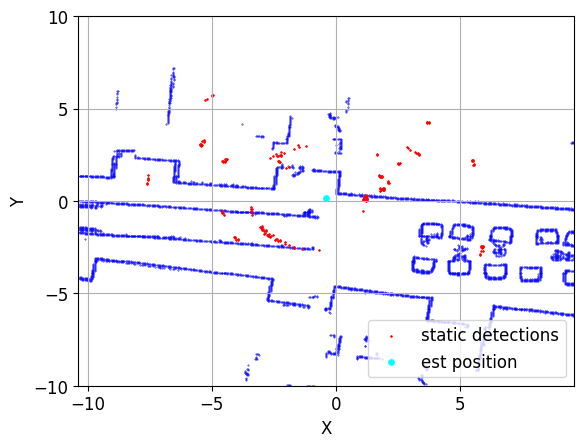

In [25]:
#recenter the point cloud grids
pc_grids_static = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_static,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)

pc_grid_dynamic = test_bench.point_cloud_stacker.recenter_pc_grids(
    grids=test_bench.point_cloud_stacker.pc_grid_dynamic,
    initial_heading_rad=test_bench.point_cloud_stacker.initial_heading_rad,
    initial_pose_m=test_bench.point_cloud_stacker.initial_pose_m,
    current_heading_rad=test_bench.point_cloud_stacker.current_heading_rad,
    current_pose_m=test_bench.point_cloud_stacker.current_pose_m
)


current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grids_static[0:1])
dynamic_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(pc_grid_dynamic)

print(test_bench.point_cloud_stacker.get_rel_distance_m())
print(test_bench.point_cloud_stacker.get_elapsed_time())

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_dynamic_and_static_detections_on_map(
    static_points=current_points,
    dynamic_points = dynamic_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)
ax.set_ylim(-10,10)
plt.show()

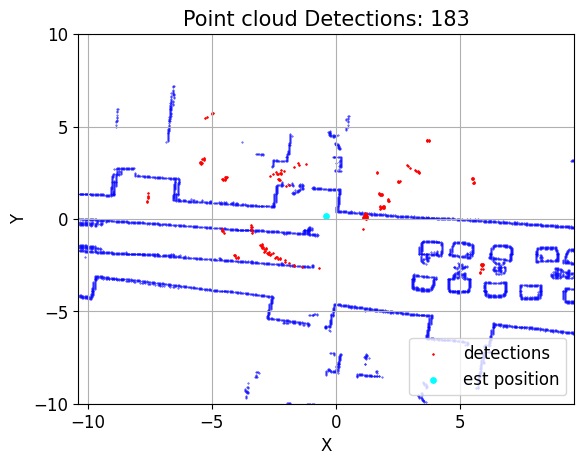

In [26]:
#remove velocity detections
current_points = \
    test_bench.point_cloud_stacker.vel_filtering.remove_dynamic_clusters_from_static_detections_knn(
        current_points,
        dynamic_points
    )

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

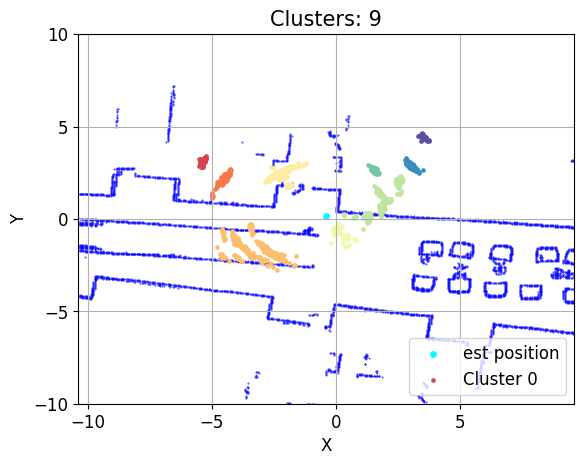

In [27]:
#perform current multi-path
multipath_num_frames_history = 2

#update the static point grid
pc_grids_static[0] = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static[0:multipath_num_frames_history+1])

labels = test_bench.point_cloud_stacker.multi_path._cluster_points(current_points)

fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detection_clusters_on_map(
    current_points=current_points,
    labels=labels,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)


ax.set_ylim(-10,10)
plt.show()

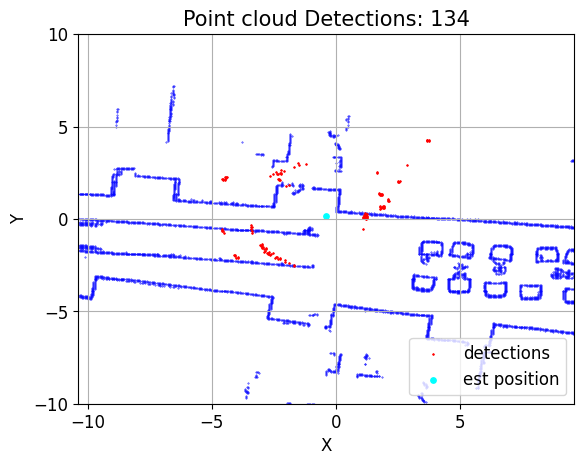

In [28]:
#remove velocity detections
current_points = test_bench.point_cloud_stacker.multi_path.remove_multipath(
    pc_cartesian=current_points
)

grid = test_bench.point_cloud_stacker._get_pc_grid_from_points(current_points)
pc_grids_static[0] = np.logical_and(grid,pc_grids_static[0])

current_points = test_bench.point_cloud_stacker._get_points_from_pc_grid(pc_grids_static[0])

# plot the lidar point cloud
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.gt_localizer.current_heading_rad,
    pose_m= test_bench.gt_localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [29]:
from tqdm import tqdm 

for i in tqdm(range(1000)):
    valid_stacked_pc_cart = test_bench.point_cloud_stacker.multi_path.remove_multipath(current_points)

100%|██████████| 1000/1000 [00:00<00:00, 1019.93it/s]


### Debugging ICP

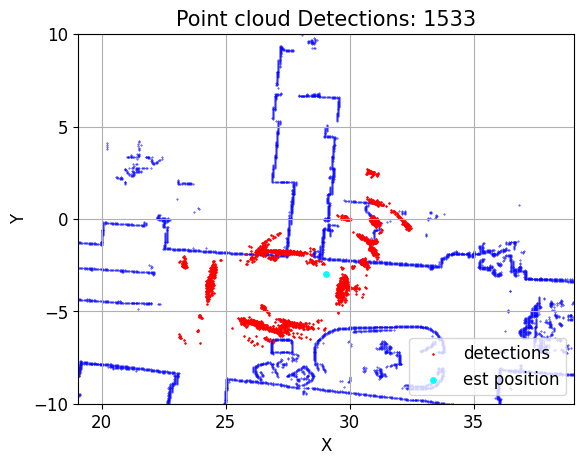

In [31]:
#get the point cloud (from the previous step)
current_points = test_bench.point_cloud_stacker._get_points_from_pc_grids(
    pc_grids_static
)
# plot the point cloud before icp
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = test_bench.localizer.current_heading_rad,
    pose_m= test_bench.localizer.current_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

In [32]:
#testing icp
icp_tb = icp2DLocalization(
    icp_matching_distance_threshold=0.1,#originally 0.1
    icp_best_points_percentile=95, #originally 65
    icp_convergence_translation_threshold=1e-3,
    icp_convergence_rotation_threshold=1e-4,
    icp_point_pairs_threshold=7, #originally 5
    icp_max_iterations=100,
    self_detection_radius_m=0 #originally 1.5
)

icp_tb.load_map_point_cloud(map_handler.map_points)

#reset the odometry
icp_tb.reset_odometry(
    pose=test_bench.filter.x[0:2],
    heading_rad=test_bench.filter.x[2]
)

#update the odometry
new_heading_rad,new_pose_m = icp_tb.update_odometry(
    points=current_points,
    estimated_heading_rad=test_bench.filter.x[2],
    estimated_pose_m=test_bench.filter.x[0:2]
)

# plot the after the icp update
fig,ax = plt.subplots()
test_bench.plotter_localization.marker_size=0.5

test_bench.plotter_localization.plot_detections_on_map(
    current_points=current_points,
    heading_rad = new_heading_rad,
    pose_m= new_pose_m,
    ax = ax,
    show = False
)

ax.set_ylim(-10,10)
plt.show()

loaded map with 20750 points


AttributeError: 'temporalCombinedPCPFTb' object has no attribute 'filter'